[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/main/docs/tutorials/flexible_inference.ipynb)

# Flexible inference with `condition_on`

One of ProbPipe's core operations is `condition_on(model, data)`. The same function call works whether the inference engine underneath is NUTS, RWMH, neural posterior estimation, neural likelihood estimation plus MCMC, neural ratio estimation plus MCMC, or sequential Monte Carlo ABC. ProbPipe inspects what the model supports (a combination of `SupportsLogProb`, `SupportsConditioning`, and `SupportsSampling`) and picks a registered method that can use it. We call this *protocol-based dispatch*, and the tutorial ends with a table showing how each engine below is reached from the same call site.

The running example is a small ecology problem. We use the **Ricker population model**, a discrete-time density-dependent growth model classic in fisheries and population biology. With deterministic dynamics, the likelihood is tractable and NUTS works fine. Flip on process noise and the likelihood becomes intractable, but the same class serves both regimes.

The engines we exercise:

- NUTS on the deterministic case, via `SimpleModel`.
- **NPE** (`learn_amortized_posterior`): amortized direct posterior sampling.
- **NLE** (`learn_amortized_likelihood`): an emulated likelihood that any MCMC backend can drive.
- **NRE** (`learn_amortized_ratio`): an emulated likelihood-to-evidence ratio, also MCMC-driven.
- **SMC-ABC** through the inference registry (shown below; runs once the `pyabc` backend is installed).

> **Prerequisites:** [Getting Started tutorial](getting_started.ipynb). The neural SBI engines (NPE/NLE/NRE) require `pip install probpipe-core[bayesflow]`; SMC-ABC requires the `pyabc` backend (a later release).

In [ ]:
# Colab setup — installs ProbPipe with the neural-SBI extra. Runs only on Google
# Colab; on local Jupyter, the docs build, and CI this block is skipped, so it
# never affects execution elsewhere.
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    import subprocess, sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install",
         "probpipe-core[viz,bayesflow] @ git+https://github.com/TARPS-group/prob-pipe@main"],
        check=True,
    )

In [1]:
import warnings; warnings.simplefilter('ignore')

import io
from contextlib import contextmanager, redirect_stderr, redirect_stdout

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
plt.rcParams['mathtext.default'] = 'regular'

from probpipe import (
    SimpleModel, SimpleGenerativeModel, Record,
    condition_on, learn_amortized_posterior, learn_amortized_likelihood,
    learn_amortized_ratio, ProductDistribution, Normal, inference_method_registry,
)
from probpipe.modeling import Likelihood, GenerativeLikelihood

# SMC-ABC arrives with the optional pyabc backend (a later release): the cells
# that use it run only when the `pyabc_smcabc` method is registered, and
# self-skip otherwise. Everything else is functional with probpipe-core[bayesflow].
HAVE_PYABC = "pyabc_smcabc" in inference_method_registry.list_methods()


@contextmanager
def silence():
    """Suppress stdout/stderr chatter (tqdm bars, training logs)."""
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield

## 1. The Ricker population model

The Ricker map is a discrete-time density-dependent growth model with an optional i.i.d. Gaussian (white) noise shock on the log-growth rate at each step:

$$N_{t+1} = N_t \exp\!\left(r \left(1 - \frac{N_t}{K}\right) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

We never observe the population $N_t$ directly — a survey *detects* a fraction $\phi \in (0, 1)$ of it, so the recorded counts are

$$y_t \mid N_t \sim \text{Poisson}(\phi\, N_t), \qquad t = 1, \ldots, T.$$

The three parameters are the intrinsic growth rate $r > 0$, the carrying capacity $K > 0$, and the detection probability $\phi \in (0, 1)$. We place the prior on the unconstrained reparameterization $\theta = (\log K, \operatorname{logit}\phi, \log r)$ — an independent product of normals — so exponentiating recovers positive $K$ and $r$, and the logistic map recovers $\phi \in (0, 1)$. The noise scale $\sigma_p$ is a fixed setting of the model: $\sigma_p = 0$ gives the deterministic Ricker (closed-form likelihood) and any $\sigma_p > 0$ gives the stochastic Ricker (intractable likelihood). We defer the stochastic case to §5.

In [2]:
T = 30        # length of the observed time series
N0 = 30.0     # initial population size (assumed known)


class RickerObservationModel(Likelihood, GenerativeLikelihood):
    """Ricker population model with Poisson detection counts.

    Inheriting from both protocols makes it explicit that this class
    supplies the two APIs ProbPipe needs: ``log_likelihood`` (used by
    MCMC on a ``SimpleModel``) and ``generate_data`` (used by SBI on a
    ``SimpleGenerativeModel``).

    Parameters arrive on the unconstrained scale ``(log K, logit phi,
    log r)`` and are mapped back to ``K, r > 0`` (exp) and ``phi`` in
    ``(0, 1)`` (the logistic). The ``sigma_p`` argument turns on Gaussian
    process noise on the log-growth rate: for ``sigma_p == 0`` the
    trajectory is deterministic and ``log_likelihood`` is the exact
    Poisson log-pmf; for ``sigma_p > 0`` the latent ``N_t`` sequence is
    stochastic and the closed-form likelihood is no longer valid --
    ``log_likelihood`` raises, and only ``generate_data`` remains.
    """

    def __init__(self, T, N0, sigma_p=0.0):
        self.T, self.N0, self.sigma_p = T, N0, sigma_p

    def _trajectory(self, params, key):
        # params arrives flat from MCMC (a parameter vector) or structured
        # from the simulator path (a per-draw record); coerce to a flat vector
        # either way. Insertion order from the prior: K, phi, r.
        theta = params.to_vector() if hasattr(params, "to_vector") else jnp.asarray(params)
        log_K, logit_phi, log_r = jnp.ravel(theta)
        K, phi, r = jnp.exp(log_K), jax.nn.sigmoid(logit_phi), jnp.exp(log_r)
        noise = self.sigma_p * jax.random.normal(key, (self.T,))
        def step(N, eps):
            Nn = N * jnp.exp(r * (1 - N / K) + eps)
            return Nn, Nn
        _, traj = jax.lax.scan(step, self.N0, noise)
        return phi * traj   # observation rate = detection probability * population

    def log_likelihood(self, params, data):
        if self.sigma_p != 0:
            raise NotImplementedError('closed-form likelihood only valid for sigma_p=0')
        rates = self._trajectory(params, jax.random.PRNGKey(0))
        return jnp.sum(jax.scipy.stats.poisson.logpmf(data, rates))

    def generate_data(self, params, num_observations, *, key=None):
        if key is None:
            key = jax.random.PRNGKey(0)
        def one_sim(k):
            k_proc, k_obs = jax.random.split(k)
            return jax.random.poisson(
                k_obs, self._trajectory(params, k_proc)
            ).astype(jnp.float32)
        return jax.vmap(one_sim)(jax.random.split(key, num_observations))


ricker = RickerObservationModel(T=T, N0=N0)  # sigma_p=0 → deterministic
assert isinstance(ricker, Likelihood)
assert isinstance(ricker, GenerativeLikelihood)

### Generate the observed series

We pick ecologically plausible "true" parameters — growth rate $r = 0.3$, carrying capacity $K = 450$, and detection probability $\phi = 0.6$ — simulate one $T = 30$ series, and treat it as the dataset to be inferred. Because $\phi = 0.6$, the recorded counts are an undercount of the true population.

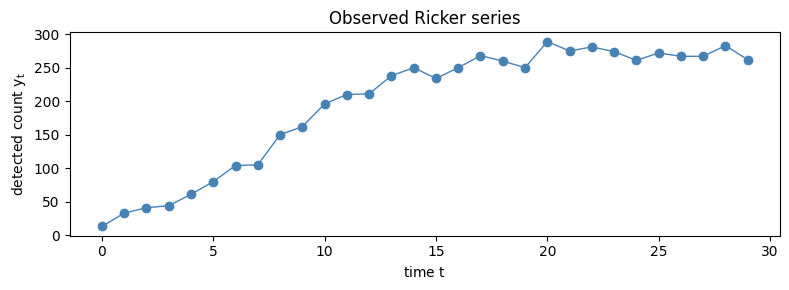

In [3]:
true_params_nat = Record(K=450.0, phi=0.6, r=0.3)
# Unconstrained (log K, logit phi, log r), in the prior's field order (K, phi, r).
true_params = jnp.array([jnp.log(450.0), jnp.log(0.6 / 0.4), jnp.log(0.3)])
y_obs = ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(0))[0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue', lw=1)
ax.set(xlabel='time $t$', ylabel='detected count $y_t$', title='Observed Ricker series')
plt.tight_layout(); plt.show()

### A broad prior on the unconstrained parameters

We center each component in the right ballpark but deliberately off the truth, with moderate scale, so inference has real work to do. The prior is an independent product of normals on $(\log K, \operatorname{logit}\phi, \log r)$. `ProductDistribution` defines this over named parameters; when all components are TFP-backed (as `Normal` is), it automatically exposes a combined TFP distribution for interop with SBI.

In [4]:
prior = ProductDistribution(Normal(loc=jnp.log(350.0), scale=0.4, name="K"),
                            Normal(loc=0.0, scale=0.8, name="phi"),   # logit scale; sigmoid(0)=0.5
                            Normal(loc=jnp.log(0.4), scale=0.4, name="r"))

## 2. MCMC via `condition_on`

Because we can write down a closed-form likelihood, the natural inference method is MCMC. We package the prior and the likelihood in a `SimpleModel` and call `condition_on`. The model satisfies `SupportsLogProb`, so the inference registry auto-selects NUTS, exactly as in the Getting Started tutorial.

In [5]:
model_mcmc = SimpleModel(prior, ricker, name='ricker_mcmc')

posterior_mcmc = condition_on(model_mcmc, y_obs)
print(f'Algorithm: {posterior_mcmc.algorithm}')

Algorithm: blackjax_nuts


In [6]:
PARAM_NAMES = ['r', 'K', 'phi']
truth_nat = {name: float(true_params_nat[name]) for name in PARAM_NAMES}

# Map each unconstrained draw back to its natural scale: K, r via exp; phi via
# the logistic, since it lives in (0, 1).
_TO_NATURAL = {'K': np.exp, 'r': np.exp, 'phi': lambda z: 1.0 / (1.0 + np.exp(-z))}


def to_natural(draws):
    """Posterior draws (a record keyed by parameter name) -> dict of natural-scale arrays."""
    return {name: _TO_NATURAL[name](np.asarray(draws[name])) for name in PARAM_NAMES}


def _fmt(label, vals, sds=None):
    sd_iter = sds if sds is not None else [None] * len(vals)
    cols = '   '.join(
        f'{n} = {m:7.2f}' + (f' \u00b1 {s:6.2f}' if s is not None else ' ' * 9)
        for n, m, s in zip(PARAM_NAMES, vals, sd_iter)
    )
    return f'{label:<26}{cols}'.rstrip()


def summarize(posterior, label, truth=True):
    """Print (optionally) ground truth and the posterior mean +/- 2 sd."""
    nat = to_natural(posterior.draws())
    if truth:
        print(_fmt('truth', [truth_nat[n] for n in PARAM_NAMES]))
    print(_fmt(label, [nat[n].mean() for n in PARAM_NAMES],
               [2 * nat[n].std() for n in PARAM_NAMES]))
    return nat


nat_mcmc = summarize(posterior_mcmc, 'NUTS (closed-form)')

truth                     r =    0.30            K =  450.00            phi =    0.60
NUTS (closed-form)        r =    0.31 ±   0.03   K =  523.08 ± 109.08   phi =    0.52 ±   0.11


## 3. What changes if you only have a simulator?

The Poisson-Ricker model above has a tractable likelihood because the dynamics are deterministic. But real ecological models almost always involve internal randomness (process noise, demographic stochasticity, individual-based simulators), so in practice there is no closed-form likelihood. In those settings the only thing the user can supply is a simulator.

NUTS still works on the toy Ricker, so the point here is not that you *must* switch; it is that you *can*, without changing the model class or the call site:

```python
model_sim = SimpleGenerativeModel(prior, ricker)
posterior = condition_on(model_sim, y_obs, ...)
```

`SimpleGenerativeModel` only requires `generate_data`, never `log_likelihood`. Below we walk through four SBI engines, all reached through `condition_on`.

In [7]:
model_sim = SimpleGenerativeModel(prior, ricker, name='ricker_sim')

### 3a. Amortized neural posterior estimation (NPE)

`learn_amortized_posterior` trains a neural density estimator (a BayesFlow coupling flow by default for two or more unconstrained parameter dimensions, as here; it falls back to a flow-matching network in 1-D) to approximate $p(\theta \mid y)$ as a function of $y$. It returns a `BayesFlowModel` that implements `SupportsConditioning`, so `condition_on` calls the trained network directly — one forward pass, no MCMC. The same trained model conditions on any observation of the trained shape.

In [8]:
with silence():
    npe_model = learn_amortized_posterior(prior, ricker, method='npe',
                                          num_simulations=5_000, epochs=60, batch_size=128)
    posterior_npe = condition_on(npe_model, y_obs)

nat_npe = summarize(posterior_npe, 'NPE (direct sampler)')

14:55:33.156 | INFO    | bayesflow - Using backend 'jax'

14:55:34.686 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:55:34.687 | INFO    | bayesflow - Building on a test batch.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

truth                     r =    0.30            K =  450.00            phi =    0.60
NPE (direct sampler)      r =    0.31 ±   0.04   K =  544.35 ± 197.52   phi =    0.46 ±   0.14


### 3b. Emulated likelihood + your favorite MCMC algorithm (NLE)

`learn_amortized_likelihood` trains a network to approximate $p(y \mid \theta)$ instead of the posterior. It returns a `BayesFlowLikelihood` — *just* a likelihood — which we drop into `SimpleModel(prior, learned)` and hand to `condition_on`. The learned log-density is `jax.grad`-transparent, so the standard NUTS path drives it with no special handling; any registered MCMC backend would work.

Our observations are **Poisson counts** — integer-valued — and fitting a continuous flow directly to atoms is ill-posed (the density wants to collapse onto the integers). We pass `dequantize=True`, the recommended setting for integer-valued data: it trains on uniformly jittered counts and scores at the unit-cell midpoint, so the flow models an absolutely continuous target rather than a comb of spikes.

In [9]:
with silence():
    nle_lik = learn_amortized_likelihood(prior, ricker, num_simulations=5_000,
                                         epochs=60, batch_size=128, dequantize=True)
    posterior_nle = condition_on(SimpleModel(prior, nle_lik), y_obs)

nat_nle = summarize(posterior_nle, 'NLE + NUTS')

14:56:04.475 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:56:04.476 | INFO    | bayesflow - Building on a test batch.

truth                     r =    0.30            K =  450.00            phi =    0.60
NLE + NUTS                r =    0.31 ±   0.03   K =  524.34 ± 128.17   phi =    0.52 ±   0.12


### 3c. Emulated likelihood-to-evidence ratio (NRE)

`learn_amortized_ratio` trains a classifier to approximate the likelihood-to-evidence ratio $p(y \mid \theta) / p(y)$. Like NLE it returns a likelihood component for `SimpleModel` + `condition_on`, but the estimator is a classifier rather than a density, so it consumes the integer counts **natively** — no `dequantize` needed. The summed per-row scores equal the joint log-likelihood up to a $\theta$-independent constant, which cancels in MCMC: valid for conditioning, but not for absolute-likelihood uses such as model comparison or LOO/WAIC.

In [10]:
with silence():
    nre = learn_amortized_ratio(prior, ricker, num_simulations=5_000,
                                epochs=60, batch_size=128)
    posterior_nre = condition_on(SimpleModel(prior, nre), y_obs)

nat_nre = summarize(posterior_nre, 'NRE + NUTS')

14:56:38.297 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:56:38.298 | INFO    | bayesflow - Building on a test batch.

truth                     r =    0.30            K =  450.00            phi =    0.60
NRE + NUTS                r =    0.33 ±   0.22   K =  412.34 ± 338.08   phi =    0.52 ±   0.35


### 3d. Sequential Monte Carlo ABC

SMC-ABC is a non-amortized, likelihood-free method: it iteratively refines a particle approximation to the posterior using the simulator alone. ProbPipe registers an SMC-ABC method against `SimpleGenerativeModel` through the `pyabc` backend, so calling `condition_on` on `model_sim` with `method='pyabc_smcabc'` runs it. We supply problem-specific summary statistics (mean, standard deviation, lag-1 autocorrelation), since identity summaries don't work in $T = 40$ dimensions.

> This section runs once the `pyabc` backend is installed (a later release); until then the cell skips itself.

In [11]:
def ricker_summary(y):
    y = jnp.atleast_2d(y).astype(jnp.float32)
    m, s = y.mean(-1, keepdims=True), y.std(-1, keepdims=True)
    ac1 = jnp.mean((y[:,1:] - m) * (y[:,:-1] - m), -1, keepdims=True) / (s**2 + 1e-6)
    return jnp.concatenate([m, s, ac1], -1)


if HAVE_PYABC:
    with silence():
        posterior_abc = condition_on(model_sim, y_obs, method='pyabc_smcabc',
                                     summary_fn=ricker_summary, n_rounds=4, n_particles=500)
    nat_abc = summarize(posterior_abc, 'SMC-ABC (likelihood-free)')
else:
    nat_abc = None
    print('SMC-ABC requires the pyabc backend (a later release); skipping this cell.')

SMC-ABC requires the pyabc backend (a later release); skipping this cell.


## 4. Comparing the posteriors

All runs go through the same `condition_on` entry point, return `ApproximateDistribution` objects, and feed downstream operations (`mean`, `variance`, `sample`, `predictive_check`, ...) identically. NUTS is the gold standard here because we have a closed-form likelihood. The neural SBI backends concentrate near the truth but are broader: they pay the cost of training a surrogate rather than evaluating the exact log-density. (SMC-ABC joins the comparison once the `pyabc` backend is installed.)

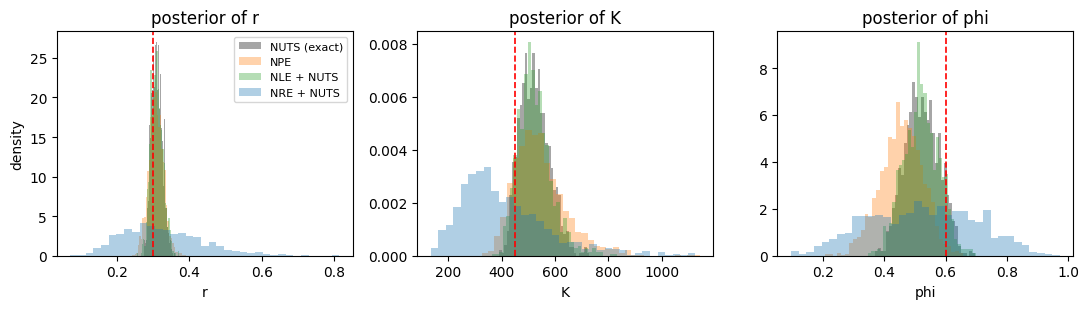

In [12]:
def plot_posteriors(posteriors, colors, truth_nat):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for ax, name in zip(axes, PARAM_NAMES):
        for (label, nat), c in zip(posteriors.items(), colors):
            ax.hist(nat[name], bins=35, density=True, alpha=0.35, color=c, label=label)
        ax.axvline(truth_nat[name], color='red', ls='--', lw=1.2)
        ax.set(xlabel=name, ylabel='density' if name == PARAM_NAMES[0] else None,
               title=f'posterior of {name}')
    axes[0].legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()


posteriors = {'NUTS (exact)': nat_mcmc, 'NPE': nat_npe,
              'NLE + NUTS': nat_nle, 'NRE + NUTS': nat_nre}
colors = ['black', 'tab:orange', 'tab:green', 'tab:blue']
if nat_abc is not None:
    posteriors['SMC-ABC'] = nat_abc
    colors.append('tab:purple')
plot_posteriors(posteriors, colors, truth_nat)

## 5. Simulation-based Inference for the Stochastic Ricker Model

Setting `sigma_p > 0` on the same class adds an independent Gaussian (white) noise shock to the log-growth rate at each time step:

$$N_{t+1} = N_t \exp\!\left(r (1 - N_t/K) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Now $N_{1:T}$ is a latent stochastic process. The integral $p(y \mid \theta) = \int p(y \mid N_{1:T}) \, p(N_{1:T} \mid \theta) \, dN_{1:T}$ has no closed form, and the closed-form Poisson `log_likelihood` from §2 is no longer valid (it would treat the noisy trajectory as if it were deterministic), so the model raises rather than silently returning a wrong answer — we added a `sigma_p == 0` check on `log_likelihood` for exactly this reason.

The simulator handles both regimes in the same code path, so the prior, the summary statistics, and the `condition_on` call site all carry over. The only difference from §3 is the model wrapper: `SimpleGenerativeModel` instead of `SimpleModel`, because there is no valid log-density to hand to gradient-based MCMC.

log_likelihood refused:  closed-form likelihood only valid for sigma_p=0


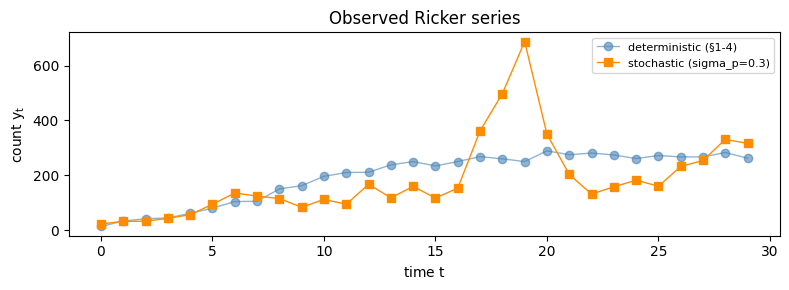

In [13]:
stoch_ricker = RickerObservationModel(T=T, N0=N0, sigma_p=0.3)

# Generate a fresh observed series from the stochastic model.
y_obs_stoch = stoch_ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(7))[0]

# Protocol check: still a GenerativeLikelihood; log_likelihood now errors on use.
assert isinstance(stoch_ricker, GenerativeLikelihood)
try:
    stoch_ricker.log_likelihood(true_params, y_obs_stoch)
except NotImplementedError as e:
    print(f'log_likelihood refused:  {e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue',
        lw=1, alpha=0.6, label='deterministic (§1-4)')
ax.plot(np.arange(T), np.asarray(y_obs_stoch), 's-', color='darkorange',
        lw=1, label='stochastic (sigma_p=0.3)')
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fit the stochastic model: only simulation-based methods apply

With no valid log-density we can't use `SimpleModel` + NUTS. We wrap the same class in `SimpleGenerativeModel` for SMC-ABC, and reuse the amortized engines, which only ever needed the simulator. Below we run NPE (and SMC-ABC when `pyabc` is available); the NLE/NRE code from §3 carries over unchanged, just pointed at `stoch_ricker`.

In [14]:
model_sim_stoch = SimpleGenerativeModel(prior, stoch_ricker)

with silence():
    npe_stoch = learn_amortized_posterior(prior, stoch_ricker, method='npe',
                                          num_simulations=5_000, epochs=60, batch_size=128)
    posterior_npe_stoch = condition_on(npe_stoch, y_obs_stoch)

nat_npe_stoch = summarize(posterior_npe_stoch, 'NPE (stochastic)')

if HAVE_PYABC:
    with silence():
        posterior_abc_stoch = condition_on(model_sim_stoch, y_obs_stoch, method='pyabc_smcabc',
                                           summary_fn=ricker_summary, n_rounds=4, n_particles=500)
    nat_abc_stoch = summarize(posterior_abc_stoch, 'SMC-ABC (stochastic)')
else:
    nat_abc_stoch = None
    print('SMC-ABC requires the pyabc backend (a later release); skipping.')

14:56:56.401 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:56:56.401 | INFO    | bayesflow - Building on a test batch.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

truth                     r =    0.30            K =  450.00            phi =    0.60
NPE (stochastic)          r =    0.27 ±   0.10   K =  351.47 ± 217.15   phi =    0.57 ±   0.19
SMC-ABC requires the pyabc backend (a later release); skipping.


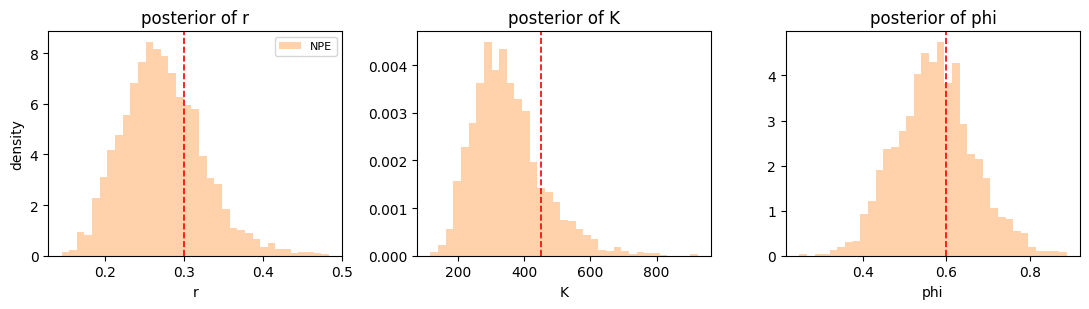

In [15]:
stoch_posteriors = {'NPE': nat_npe_stoch}
stoch_colors = ['tab:orange']
if nat_abc_stoch is not None:
    stoch_posteriors['SMC-ABC'] = nat_abc_stoch
    stoch_colors.append('tab:purple')
plot_posteriors(stoch_posteriors, stoch_colors, truth_nat)

## 6. The real thing: moose counts, same three lines

Everything above used simulated data so we could check recovery against a known truth. The payoff is that **nothing changes** when the data are real. Below are annual moose (*Alces alces*) census counts, 1967–1988 — a gap-free stretch of a longer survey, with the characteristic growth-then-saturation shape. Real populations have process noise, so the likelihood is intractable; we reach for the same simulation-based engines through the same `condition_on` call.

We model the counts as Poisson detections of a noisy latent population (`sigma_p > 0`), fix a plausible initial size, and fit the detection-corrected Ricker. (The amortized methods condition on a fixed-length series, so we use the gap-free 1967–1988 window; the full census has survey gaps that would otherwise need imputation.)

In [16]:
# Annual moose counts, 1967-1988 (gap-free window of the `alcesdata` census).
moose = jnp.array([33, 49, 68, 54, 101, 109, 102, 114, 143, 171, 198, 209,
                   178, 170, 198, 272, 258, 247, 212, 296, 259, 279], dtype=jnp.float32)
moose_years = np.arange(1967, 1989)
moose_ricker = RickerObservationModel(T=moose.size, N0=50.0, sigma_p=0.1)

# The same three engines, the same condition_on, now on real data.
with silence():
    moose_npe = condition_on(
        learn_amortized_posterior(prior, moose_ricker, method='npe',
                                  num_simulations=5_000, epochs=60, batch_size=128),
        moose)
    moose_nle = condition_on(
        SimpleModel(prior, learn_amortized_likelihood(
            prior, moose_ricker, num_simulations=5_000, epochs=60,
            batch_size=128, dequantize=True)), moose)
    moose_nre = condition_on(
        SimpleModel(prior, learn_amortized_ratio(
            prior, moose_ricker, num_simulations=5_000, epochs=60, batch_size=128)), moose)

for label, post in [('NPE', moose_npe), ('NLE + NUTS', moose_nle), ('NRE + NUTS', moose_nre)]:
    summarize(post, label, truth=False)

14:57:21.736 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:57:21.737 | INFO    | bayesflow - Building on a test batch.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

14:57:46.803 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:57:46.803 | INFO    | bayesflow - Building on a test batch.

14:58:18.385 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

14:58:18.386 | INFO    | bayesflow - Building on a test batch.

NPE                       r =    0.28 ±   0.11   K =  430.73 ± 196.32   phi =    0.54 ±   0.19
NLE + NUTS                r =    0.29 ±   0.09   K =  439.54 ± 179.89   phi =    0.56 ±   0.17
NRE + NUTS                r =    0.28 ±   0.24   K =  480.28 ± 376.46   phi =    0.51 ±   0.35


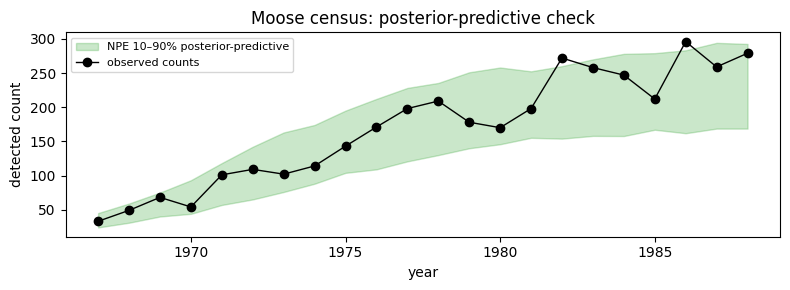

In [17]:
# Posterior-predictive check: simulate one replicate count series per posterior
# draw and overlay their 10-90% band on the observed counts. draws[f], keyed by
# 'K'/'phi'/'r', holds the unconstrained (log K, logit phi, log r) value the
# simulator expects, in field order; vmap runs all draws in one batched call.
draws = moose_npe.draws()
theta_draws = np.stack([np.asarray(draws[f]) for f in ('K', 'phi', 'r')], axis=-1)
idx = np.linspace(0, theta_draws.shape[0] - 1, 150).astype(int)
keys = jax.random.split(jax.random.PRNGKey(1), idx.size)
with silence():
    reps = np.asarray(jax.vmap(lambda th, k: moose_ricker.generate_data(th, 1, key=k)[0])(
        jnp.asarray(theta_draws[idx]), keys))
lo, hi = np.percentile(reps, [10, 90], axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(moose_years, lo, hi, color='tab:green', alpha=0.25,
                label='NPE 10–90% posterior-predictive')
ax.plot(moose_years, np.asarray(moose), 'o-', color='black', lw=1, label='observed counts')
ax.set(xlabel='year', ylabel='detected count', title='Moose census: posterior-predictive check')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Protocol-based dispatch

The tutorial has shown `condition_on` reaching several engines without touching the call site. The broader picture is that protocols are ProbPipe's unit of composition: a model exposes a set of capabilities, an inference method declares which capabilities it consumes, and the registry matches them at call time. Swapping NUTS for an emulated likelihood meant registering one class against `SupportsLogProb`, and nothing else in the pipeline had to know.

| Model class | Protocols satisfied | `condition_on` dispatches to |
|---|---|---|
| `SimpleModel(prior, ricker)` | `SupportsLogProb` | NUTS (or HMC / RWMH / nutpie / ...) picked by the inference registry |
| `BayesFlowModel` (from `learn_amortized_posterior`) | `SupportsConditioning` | Direct call into the trained network; no registry lookup |
| `SimpleModel(prior, learned)` (from `learn_amortized_likelihood` / `learn_amortized_ratio`) | `SupportsLogProb` | Any registered MCMC backend, selected automatically or via `method=` |
| `SimpleGenerativeModel(prior, ricker)` | `SupportsSampling` (a joint draw of parameters and simulated data; no log-density) | SMC-ABC (`pyabc_smcabc`), registered by the `pyabc` backend |

The same pattern drives the rest of the library: the converter registry matches distribution-to-distribution conversions, `@workflow_function` pushes forward whatever capabilities the input declares, and `predictive_check` negotiates the sampling and data-generation steps the same way. Extending ProbPipe is mostly "add a class and register it" rather than "edit inference, sampling, and downstream analysis separately".

### References

- Ricker, W.E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Wood, S.N. (2010). [Statistical inference for noisy nonlinear ecological dynamic systems](https://doi.org/10.1038/nature09319). *Nature*, 466, 1102–1104.
- Cranmer, K., Brehmer, J. & Louppe, G. (2020). [The frontier of simulation-based inference](https://doi.org/10.1073/pnas.1912789117). *PNAS*, 117(48), 30055–30062.
- Papamakarios, G. & Murray, I. (2016). [Fast ε-free inference of simulation models with Bayesian conditional density estimation](https://papers.nips.cc/paper/6084). *NeurIPS 2016*. (NPE)
- Papamakarios, G., Sterratt, D. & Murray, I. (2019). [Sequential neural likelihood](https://proceedings.mlr.press/v89/papamakarios19a.html). *AISTATS 2019*. (NLE)
- Hermans, J., Begy, V. & Louppe, G. (2020). [Likelihood-free MCMC with amortized approximate ratio estimators](https://proceedings.mlr.press/v119/hermans20a.html). *ICML 2020*. (NRE)
- Radev, S.T. et al. (2023). [BayesFlow: Amortized Bayesian workflows with neural networks](https://doi.org/10.21105/joss.05702). *JOSS*, 8(89), 5702.
- Sisson, S.A., Fan, Y. & Beaumont, M.A. (2007). [Sequential Monte Carlo without likelihoods](https://doi.org/10.1073/pnas.0607208104). *PNAS*, 104(6), 1760–1765. (SMC-ABC)

- Dietze, M.C. (2017). *Ecological Forecasting*. Princeton University Press. State-space population models; the moose (*Alces alces*) count series in §6 is the `alcesdata` census from the [EE509 course materials](https://github.com/mdietze/EE509).

## Next steps

- [**API Reference**](../api/inference.md) — full list of registered inference methods, model wrappers, and the `condition_on` operation.
- [**User Guide**](../user_guide.md) — focused examples for individual features.